# 12.1.2 异步顺序与边界

## 学习目标与先修知识

在同一更新预算下区分原地顺序和边界效应。

先修：12.1.1 双缓冲同步规则；会根据索引遍历列表。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一行格子按从左到右原地更新，左边刚写的值会影响右边。这样的结果与同步更新（synchronous update）不同，究竟是程序错误还是另一种模型（model）？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

固定同一初态、同样每轮 n 次更新，只更换时序：同步一次算完，异步按索引原地改写。

In [2]:
print('四格 [1,0,0,0]：同步 → [0,1,0,1]；从左到右原地异步 → [0,0,0,0]。')

四格 [1,0,0,0]：同步 → [0,1,0,1]；从左到右原地异步 → [0,0,0,0]。


## 模型假设

异步规则明确每轮按 order 全排列逐格更新且立即生效；同步规则各格只读旧行。每轮都更新 n 格，因此事件（event）预算一致。仍只使用本篇的二值异或规则；实际生物个体更新次序需另有证据。

## 数学解释与推导

同步映射写作 $\mathbf x^{t+1}=F(\mathbf x^t)$。异步顺序 $\sigma=(\sigma_1,\ldots,\sigma_n)$ 则为局部算子复合 $F_{\sigma_n}\circ\cdots\circ F_{\sigma_1}(\mathbf x^t)$，一般不等于同步 $F$，交换顺序也不一定保持结果。周期与固定边界（fixed boundary）改变的是邻域；更新时序改变的是读写因果。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ca_step(state, boundary, mode, order):
    """Binary rule 90: the next bit is the XOR of its two old/current neighbors."""
    n = len(state)
    result = list(state)

    def neighbor(values, index):
        if boundary == 'periodic':
            return values[index % n]
        return values[index] if 0 <= index < n else 0

    if mode == 'sync':
        old = list(state)
        return [neighbor(old, i - 1) ^ neighbor(old, i + 1) for i in range(n)]
    for i in order:
        result[i] = neighbor(result, i - 1) ^ neighbor(result, i + 1)
    return result


def ca_run(state, boundary, mode, order, steps):
    history = [list(state)]
    for _ in range(steps):
        history.append(ca_step(history[-1], boundary, mode, order))
    return history

## 对照实验

同一初态在两种时序和两种边界下运行，比较时间图和每轮激活比例。

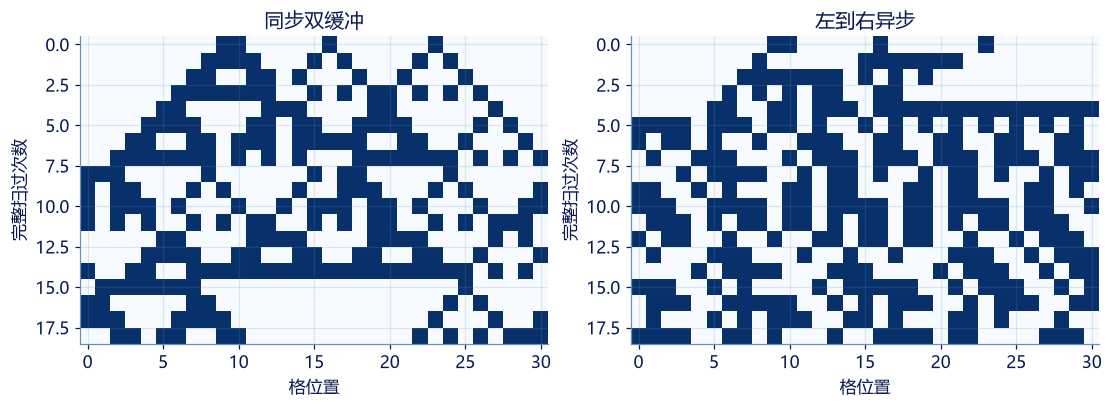

首轮激活比例：同步 0.25806451612903225 异步 0.25806451612903225


In [4]:
n=31; initial=[0]*n
for i in [9,10,16,23]: initial[i]=1
order=list(range(n))
sync=ca_run(initial,'periodic','sync',order,18)
async_history=ca_run(initial,'periodic','async',order,18)
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,history,title in zip(axes,[sync,async_history],['同步双缓冲','左到右异步']):
    ax.imshow(history,aspect='auto',interpolation='nearest',cmap='Blues',vmin=0,vmax=1)
    ax.set(xlabel='格位置',ylabel='完整扫过次数',title=title)
plt.show()
print('首轮激活比例：同步',sum(sync[1])/n,'异步',sum(async_history[1])/n)

## 结果解释

时序不同会改变宏观比例和图案，不能因为更新次数相同便认为两个程序实现同一机制。边界是另一个独立实验条件，比较时须分别固定。

### 独立核对

用最小四格例验证两种时序确实不同，并核对每轮长度与值域。

In [5]:
s=[1,0,0,0]
assert ca_step(s,'periodic','sync',[0,1,2,3])==[0,1,0,1]
assert ca_step(s,'periodic','async',[0,1,2,3])==[0,0,0,0]
assert all(len(row)==n and set(row)<={0,1} for row in sync+async_history)
print('原地读写的反例和状态合法性通过。')

原地读写的反例和状态合法性通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按指定顺序演化局部状态

使用上一题的左右邻居异或规则。mode 为 sync 或 async；async 按 order 给出的完整节点排列原地更新，每步复用此顺序。返回含初态的 steps+1 行轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    state: list[int],
    boundary: str,
    mode: str,
    order: list[int],
    steps: int,
) -> list[list[int]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 二值初态。 | 类别 |
| `boundary` | `str` | periodic 或 fixed。 | 类别 |
| `mode` | `str` | sync 或 async。 | 类别 |
| `order` | `list[int]` | 异步遍历顺序，恰好覆盖各节点一次。 | 编号 |
| `steps` | `int` | 完整扫过次数。 | 轮 |

**返回值**

直接返回 history（list[list[int]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[int]]` | 含初态的逐轮状态（state）。 | 类别 |

**计算规则**

sync 每轮统一读取旧行；async 每轮按 order 原地改写。每轮均更新 n 次，比较预算相同。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 二值初态。 | [1, 0, 0, 0] | 类别 |
| boundary | periodic 或 fixed。 | periodic | 类别 |
| mode | sync 或 async。 | sync | 类别 |
| order | 异步遍历顺序，恰好覆盖各节点一次。 | [0, 1, 2, 3] | 编号 |
| steps | 完整扫过次数。 | 2 | 轮 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 0, 0, 0]
boundary = 'periodic'
mode = 'sync'
order = [0, 1, 2, 3]
steps = 2

result = solve(state, boundary, mode, order, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 含初态的逐轮状态（state）。 | [[1, 0, 0, 0], [0, 1, 0, 1], [0, 0, 0, 0]] | 类别 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1, 0, 0, 0], [0, 1, 0, 1], [0, 0, 0, 0]]
```

**样例解释**

同一初态与事件（event）预算下，异步顺序可改变结果；题目固定顺序以便复现。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按指定顺序演化局部状态](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-ca-trajectory)

### 第 2 题 · 单项选择题：改变遍历顺序

固定初态和异或规则，只改变异步更新（asynchronous update）的 order。哪个判断成立？

- **A.** 结果可能改变，必须记录顺序。
- **B.** 只要每格更新一次，结果总相同。
- **C.** 异步一定比同步更精确。
- **D.** 遍历顺序等于物理空间位置。

[作答：改变遍历顺序](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-async-order)

### 第 3 题 · 单项选择题：固定边界的读值

fixed 边界外记0，首格计算左邻居时应读到什么？

- **A.** 0。
- **B.** 最后一格。
- **C.** 本步第二格的新值。
- **D.** 随机节点。

[作答：固定边界的读值](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-fixed-boundary)

### 第 4 题 · 单项选择题：公平比较的时间单位

同步与异步规则的演化图不同。要比较一次“扫过”的效果，首先应怎样对齐？

- **A.** 每轮均让每个格子更新一次并声明顺序。
- **B.** 只对齐动画帧率。
- **C.** 同步跑10轮、异步跑1次事件（event）。
- **D.** 删去边界说明。

[作答：公平比较的时间单位](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-update-budget)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)介绍局部规则；本节将时序作为可检验的模型条件。